<style>
    span.uvk {
        font-family: sans-serif;
    }
</style>

# Tutorial: basics of notebook authoring

The following assumes that you have completed the [installation](../install)
of <span class="uvk">uvk</span> so that your Jupyter launcher shows something like the following
screenshot (perhaps with a different [display name](../reference/uvk_cli#kernel-spec-denomination)):

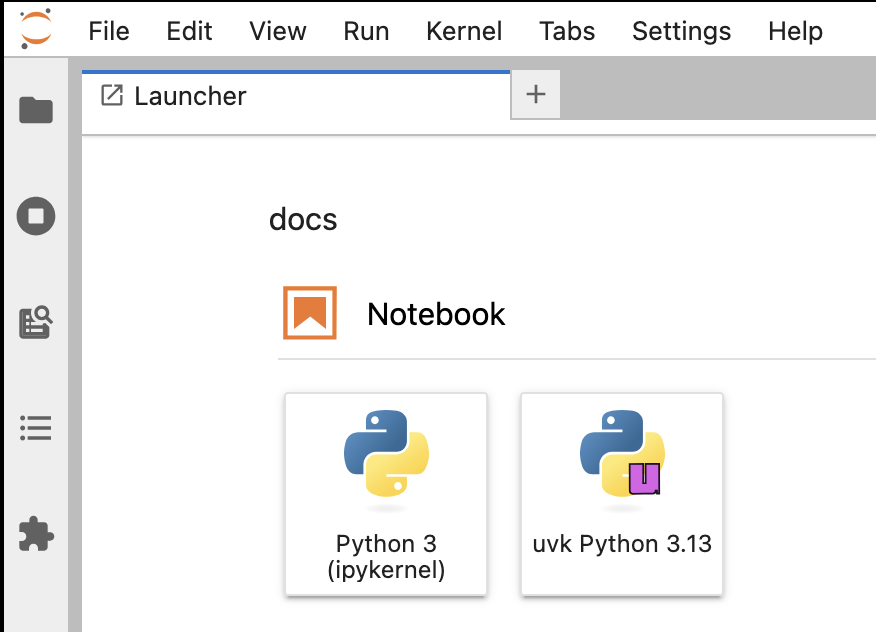


A notebook like the current tutorial ([source on Github](https://github.com/hamelin/uvk/blob/main/docs/tutorial.ipynb)) can be created by clicking on the **Python 3 (uvk)** (or **uvk dev**) launcher button,
or by changing the kernel of an existing notebook (menu **Kernel** / **Change Kernel...**).
To re-run this tutorial notebook, ensure to select a <span class="uvk">uvk</span> kernel.

When it starts, the <span class="uvk">uvk</span> kernel scans the associated notebook for [inline script metadata](https://packaging.python.org/en/latest/specifications/inline-script-metadata/),
a snippet of TOML-encoded metadata commented out and framed between special header and footer lines.
Here is an example:

```python
# /// script
# require-python = ">=3.13,<3.14.2"
# dependencies = [
#     "numpy",
#     "scikit-learn",
# ]
# ///
```

**uv** parses [scripts](https://docs.astral.sh/uv/guides/scripts/#running-a-script-with-dependencies) ahead of starting the Python interpreter
so as to build up environments populated with the script's requirements on the fly,
as well as use a Python interpreter that satisfies the script's constraint.
**uv** even assists with the management of dependencies,
through its `uv add --script` and `uv remove --script` commands.

<span class="uvk">uvk</span> kernels similarly assist in putting together the same kind of inline script metadata for notebooks,
and makes use of **uv**'s script setup logic to start kernels that meet the notebook's requirements.
<span class="uvk">uvk</span> does that with an [IPython extension](reference/ext.ipynb).
We first load it:

In [3]:
%load_ext uvk

This extension adds to the kernel a single [magic](https://ipython.readthedocs.io/en/stable/interactive/magics.html)
function named `uvk`.
It can be used either as a line or as a cell magic.
Use it as a line magic to create a new metadata cell.

In [2]:
%uvk -p >=3.11

UsageError: Line magic function `%uvk` not found.


<a id="metadata-is-here"></a>

In [ ]:
# /// script
# require-python = ">=3.11"
# dependencies = []
# ///

As seen here, the cell is created distinct from the `%uvk` call.
Then one can add their dependencies by using `uvk` as a cell magic instead.
This has the effect of changing the metadata cell _in place_.

Here is a copy of the cell above, with a `%%uvk` call that adds a pair of dependencies:

In [ ]:
%%uvk --add numpy "pandas > 3"
# /// script
# require-python = ">=3.13"
# dependencies = []
# ///

Running this cell yields:

In [3]:
# /// script
# require-python = ">=3.13"
# dependencies = ["numpy", "pandas>3"]
# ///

Modifying the metadata cell in this manner leaves behind as few `%load_ext` or `%uvk` calls to remove afterwards as possible.
Once the kernel is restarted, it will run in an environment where the requested dependencies are installed,
using a Python interpreter that satisfies the given constraint.

<div class="admonition warning">
    <p class="admonition-title">
        Which metadata cell is taken as the notebook's metadata?
    </p>
    <strong>
        Answer: the topmost cell where a metadata header comment is detected.
    </strong>
    <p>
        When starting a kernel,
        <span class="uvk">uvk</span> scans the <a href="https://earthdatascience.org/courses/intro-to-earth-data-science/open-reproducible-science/jupyter-python/code-markdown-cells-in-jupyter-notebook/">code cells</a>
        of the notebook,
        and stops at the first cell out of which a metadata header (<samp>#&nbsp;///&nbsp;script</samp>) is parsed.
        In the case of the current notebook,
        it is <a href="#metadata-is-here">this cell</a>
        (created by invoking <code>%uvk</code> as a line magic).
    </p>
    <p>
        <span class="uvk">uvk</span> then tries to parse the lines that follow into a metadata snippet,
        down to the footer (<samp>#&nbsp;///</samp>).
        <strong>If this parsing fails, the kernel does not start.</strong>
        It is up to the user to ensure they have only one metadata cell to avoid any confusion,
        and to ensure this cell is syntactically valid (comment pound sign starting each line,
        proper header, footer, and TOML syntax).
    </p>
</div>